# **Züri wie neu Reports Category Analysis**

Author: Tim Berger  
Date: 20.5.2026
<br>
<br>

### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city.  
Reports are sorted in different categories, such as waste or graphity.  
By identifying the categories with the most reports, we can determine what disturbs the residents of Zurich the most or which category suffers the most damage.
<br>
<br>

### Research Question: 
which categories of the infrastructure of Zürich experiences the most damage that bothers the residents?
<br>
<br>

### Requirements
See README file
<br>
<br>

### **Import Required Packages and Scripts**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import notebook_utils

### **Load Data from the Website of the City of Zürich**

In [2]:
# the notebook_utils file contains the functions to load the required data
# if a dataset failed to load, the corresponding url should be checked

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"

zwn_gdf_raw = notebook_utils.import_geografic_data(url_zwn)


data loaded successfully


### **Clean and Filter the Data**

In [3]:
# filter for the required columns
zwn_df = zwn_gdf_raw[["service_request_id", "title", "service_name", "requested_datetime"]].copy()

# print dates of the oldest and newest report
print(f"The data contains reports from the {min(zwn_df["requested_datetime"]).date().strftime("%d/%m/%Y")} to the {max(zwn_df["requested_datetime"]).date().strftime("%d/%m/%Y")}.")

# have a look at the data
zwn_df.head(5)

The data contains reports from the 14/03/2013 to the 21/05/2026.


,service_request_id,title,service_name,requested_datetime
0,1,Auf dem Asp,Strasse/Trottoir/Platz,2013-03-14 15:16:15
1,2,Vermessungs,Strasse/Trottoir/Platz,2013-03-14 15:17:57
2,4,Beim Trotto,Strasse/Trottoir/Platz,2013-03-15 09:14:16
3,5,Auf dem Par,Strasse/Trottoir/Platz,2013-03-15 09:17:15
4,6,Arbeitskist,Abfall/Sammelstelle,2013-03-15 10:36:53


### **Agregate and Normalize**

- agregate the data to have the number of reports per category

In [4]:
#count the reports per category and safe it as a dataframe
zwn_categories = zwn_df["service_name"].value_counts().copy().to_frame()

#rename the column and index
zwn_categories = zwn_categories.rename(columns={"count":"count_reports"}, index={"service_name": "category"})


- normalize counts per year

In [5]:
# calculate the time between the oldest and newest report
time_diff = max(zwn_df["requested_datetime"])- min(zwn_df["requested_datetime"])

#add a column with the reports per year
zwn_categories["reports_per_day"] = round(zwn_categories["count_reports"] / time_diff.days, 2)

# check the top of the table
print(zwn_categories.head(5))

                           count_reports  reports_per_day
service_name                                             
Abfall/Sammelstelle                27670             5.75
Signalisation/Lichtsignal          11061             2.30
Strasse/Trottoir/Platz              9924             2.06
Grünflächen/Spielplätze             7310             1.52
Beleuchtung/Uhren                   5430             1.13


## **Plot Data**

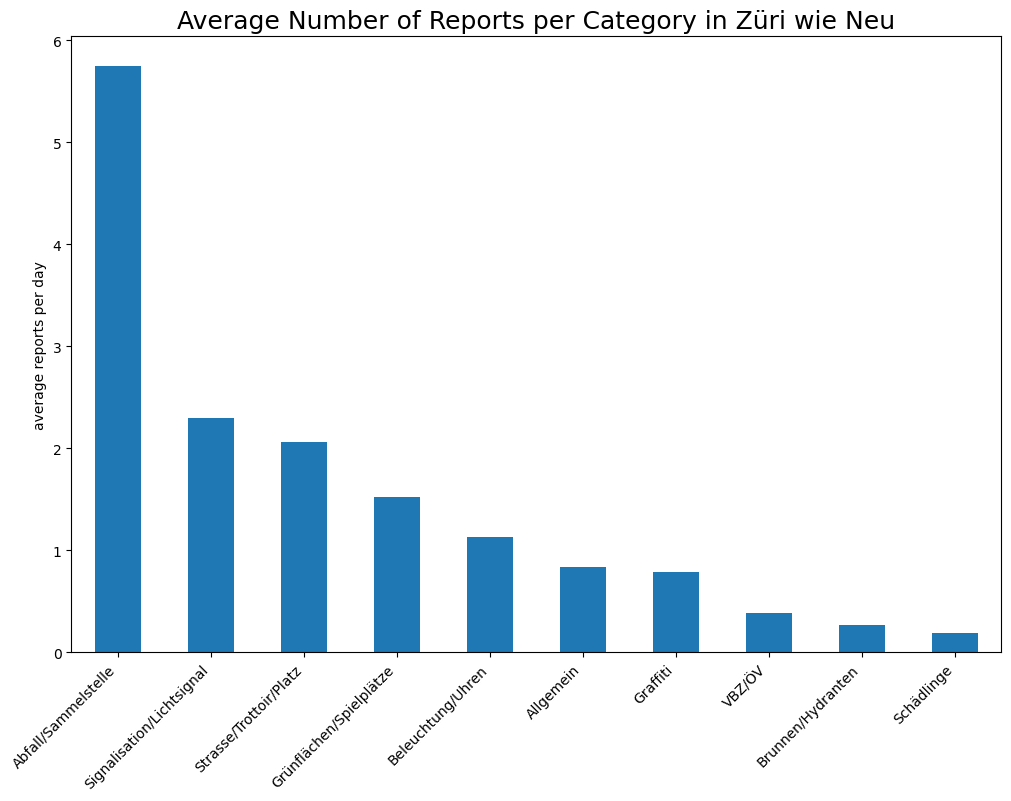

In [7]:
fig, ax = plt.subplots(figsize = (12,8))

#plot the reports per category as a barplot
zwn_categories["reports_per_day"].plot(kind="bar", ax=ax,
                                       xlabel="",
                                       ylabel="average reports per day")

#set title
ax.set_title("Average Number of Reports per Category in Züri wie Neu", fontsize=18)

#rotate neighbourhood labels on the x axis
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")

# save figure in the figures folder
fig.savefig("../figures/reports_categories_bar.png", dpi=300, bbox_inches="tight")

# show plot
plt.show()

### **Results**

The 'Waste/Collection Site' category contains by far the most reports, with an average of almost 6 reports per day.  
The second most frequent category is 'Signalisation/Traffic Light' with over 2 reports per day.  
From the second to the smallest category, 'Vermin', there is about a linear decrease in reports per category.